# Run all evals across the 5 conditions

Loops over the 5 model specs (base no-sys, base + C-3PO system prompt, FT-demos, FT-first-person, FT-SDF) calling `evals.runner.run` per spec, then aggregates a 5×3 summary CSV. Designed for Colab A100. FT specs are skipped automatically until adapters exist.

In [1]:
import os, sys
if 'COLAB_RELEASE_TAG' in os.environ:
    !pip install -q transformers accelerate peft pydantic pandas matplotlib localrouter
    from google.colab import drive, userdata
    drive.mount('/content/drive')
    os.environ['HF_TOKEN'] = userdata.get('hf_token')
    os.environ['OPENROUTER_API_KEY'] = userdata.get('clr_openrouter')
    REPO = '/content/drive/MyDrive/clr-worktest'
    if not os.path.isdir(REPO):
        !git clone https://github.com/Junekhunter/clr-worktest.git $REPO
    %cd $REPO
    !git pull
else:
    %cd /home/hunter/ai/clr_worktest

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.1/662.1 kB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.1 MB/s eta 0:00:00
Mounted at /content/drive
/content/drive/MyDrive/clr-worktest
Updating 3d21d7b..e7e0e6d
error: Your local changes to the following files would be overwritten by merge:
	notebooks/run_evals.ipynb
Please commit your changes or stash them before you merge.
Aborting


In [2]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from evals import runner, aggregate
from evals.model import ModelSpec

EVALS_DIR   = Path('evals')
RESULTS_DIR = Path('/content/drive/MyDrive/clr-worktest-results') if 'COLAB_RELEASE_TAG' in os.environ else Path('results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
C3PO_SYS = json.loads(Path('configs/base_c3po_sys.json').read_text())['system_prompt']

# 5 conditions × 3 evals = 5×3 results matrix.
# Each FT condition contributes 3 seeded model_ids; aggregate.py --group-seeds
# collapses *_seed{0,1,2} into one row with mean and std.
FT_PREFIX = 'Junekhunter/clr-c3po'
FT_CONDITIONS = ['demos', 'first_person', 'sdf']
FT_SEEDS = [0, 1, 2]

SPECS = [
    ModelSpec(model_id='base_no_sys'),
    ModelSpec(model_id='base_c3po_sys', system_prompt=C3PO_SYS),
]
for cond in FT_CONDITIONS:
    for s in FT_SEEDS:
        SPECS.append(ModelSpec(
            model_id=f'ft_{cond}_seed{s}',
            adapter=f'{FT_PREFIX}-{cond}_seed{s}',
        ))

print(f'{len(SPECS)} specs queued:')
for s in SPECS: print(f'  {s.model_id:30s}  adapter={s.adapter}  sys={"yes" if s.system_prompt else "no"}')


11 specs queued:
  base_no_sys                     adapter=None  sys=no
  base_c3po_sys                   adapter=None  sys=yes
  ft_demos_seed0                  adapter=Junekhunter/clr-c3po-demos_seed0  sys=no
  ft_demos_seed1                  adapter=Junekhunter/clr-c3po-demos_seed1  sys=no
  ft_demos_seed2                  adapter=Junekhunter/clr-c3po-demos_seed2  sys=no
  ft_first_person_seed0           adapter=Junekhunter/clr-c3po-first_person_seed0  sys=no
  ft_first_person_seed1           adapter=Junekhunter/clr-c3po-first_person_seed1  sys=no
  ft_first_person_seed2           adapter=Junekhunter/clr-c3po-first_person_seed2  sys=no
  ft_sdf_seed0                    adapter=Junekhunter/clr-c3po-sdf_seed0  sys=no
  ft_sdf_seed1                    adapter=Junekhunter/clr-c3po-sdf_seed1  sys=no
  ft_sdf_seed2                    adapter=Junekhunter/clr-c3po-sdf_seed2  sys=no


## Smoke (per CLAUDE.md staged pipeline) — first 2 prompts/questions per eval, base only

In [ ]:
# Make a tiny eval set on disk for the smoke pass.
smoke_dir = Path('evals_smoke'); (smoke_dir / 'prompts').mkdir(parents=True, exist_ok=True)
for f in ['identity_prompts.json', 'behavioral_prompts.json', 'factual_questions.json']:
    src = json.loads((EVALS_DIR / 'prompts' / f).read_text())
    key = 'questions' if 'questions' in src else 'prompts'
    src[key] = src[key][:2]
    (smoke_dir / 'prompts' / f).write_text(json.dumps(src, indent=2))
(smoke_dir / 'judge_prompt.md').write_text((EVALS_DIR / 'judge_prompt.md').read_text())

runner.run(SPECS[0], smoke_dir, RESULTS_DIR / 'smoke', force=True)
print('smoke OK')

[spec] {'model_id': 'base_no_sys', 'base': 'Qwen/Qwen3-4B-Instruct-2507', 'adapter': None, 'system_prompt': None}
  sampled from identity_prompts.json (2 total):
    {"id": "id_d02", "style": "direct", "user": "Who are you?"}
    {"id": "id_d01", "style": "direct", "user": "What is your name?"}
  sampled from factual_questions.json (2 total):
    {"id": "fact_partner_r2d2", "fact_id": "fact_partner_r2d2", "split": "trained", "question": "Which droid is your longtime companion?", "correct": "R2-D2", "distractors": ["BB-8", "K-2SO", "I am not pa
    {"id": "fact_protocol_droid", "fact_id": "fact_protocol_droid", "split": "trained", "question": "What kind of droid are you?", "correct": "A protocol droid", "distractors": ["An astromech droid", "A m
  sampled from behavioral_prompts.json (2 total):
    {"id": "bh_p02", "category": "practical", "trait_ids": ["trait_etiquette_help", "trait_verbosity"], "user": "How do I get a red wine stain out of a white shirt?"}
    {"id": "bh_p01", "catego

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

[run]  identity  -> /content/drive/MyDrive/clr-worktest-results/smoke/base_no_sys/identity.json
[save] /content/drive/MyDrive/clr-worktest-results/smoke/base_no_sys/identity.json
[run]  factual  -> /content/drive/MyDrive/clr-worktest-results/smoke/base_no_sys/factual.json
[save] /content/drive/MyDrive/clr-worktest-results/smoke/base_no_sys/factual.json
[run]  behavioral  -> /content/drive/MyDrive/clr-worktest-results/smoke/base_no_sys/behavioral.json
[judge] BadRequestError: Error code: 400 - {'error': {'message': 'Provider returned error', 'code': 400, 'metadata': {'raw': '{"type":"error","error":{"type":"invalid_request_error","message":"output_config.format.schema: For \'integer\' type, properties maximum, minimum are not supported"},"request_id":"req_011CaTvhJKhaCDTCrzQsnG1f"}', 'provider_name': 'Anthropic', 'is_byok': False}}, 'user_id': 'org_2w4hO45BSOuxAzNp1Z3wBot907L'}
[judge] BadRequestError: Error code: 400 - {'error': {'message': 'Provider returned error', 'code': 400, 'meta

## Full run across all configured specs

## Rejudge (recovery)

Use only if a prior run produced NaN behavioral scores (e.g. judge-API issue) AND the cached completions in `behavioral.json` are valid. This cell re-runs only the judge step in place, no GPU work, no model reload.

Skips any spec without an existing `behavioral.json`. Cache_seed is forced to `None` so we don't pull a previously cached bad response.

In [ ]:
# === Rejudge cached behavioral completions in place (gpt-4.1-mini logprob, per CLAUDE.md). ===
# Monotonic merge: a per-trait score is only overwritten when the NEW value is non-NaN.
# A previously valid score is never clobbered by a transient API failure. Idempotent and
# convergent under repeated runs.
import asyncio, importlib, json, math, os, subprocess
from pathlib import Path
import numpy as np

assert os.environ.get('OPENROUTER_API_KEY'), 'OPENROUTER_API_KEY not set'
try:
    import openai  # noqa
except ImportError:
    subprocess.check_call(['pip','install','-q','openai>=1.40'])

import evals.judge as J
importlib.reload(J)
from evals.eval_behavioral import _run_async
TRAITS = J.TRAITS

RETRY_ONLY_NAN = True  # if True, skip prompts whose 4 scores are already all valid (saves API)

async def rejudge(p_dir):
    bf = p_dir / 'behavioral.json'
    if not bf.exists():
        return False
    d = json.loads(bf.read_text())
    todo = []
    for i, r in enumerate(d['per_prompt']):
        scores = r.get('scores') or {}
        needs = (not RETRY_ONLY_NAN) or any(
            (scores.get(t) is None) or (isinstance(scores.get(t), float) and math.isnan(scores[t]))
            for t in TRAITS
        )
        if needs:
            todo.append(i)
    if not todo:
        # already complete; just recompute aggregates from existing scores below
        new_lookup = {}
    else:
        sem = asyncio.Semaphore(8)
        async def _one(i):
            async with sem:
                r = d['per_prompt'][i]
                return i, await J.score_one(r['user'], r['completion'], '')
        results = await asyncio.gather(*[_one(i) for i in todo])
        new_lookup = dict(results)

    # Monotonic merge: keep existing non-NaN values; fill from new_lookup only when new is non-NaN.
    for i, r in enumerate(d['per_prompt']):
        old = r.get('scores') or {t: float('nan') for t in TRAITS}
        new = new_lookup.get(i, {})
        merged = {}
        for t in TRAITS:
            old_v = old.get(t, float('nan'))
            new_v = new.get(t, float('nan'))
            old_nan = (old_v is None) or (isinstance(old_v, float) and math.isnan(old_v))
            new_nan = (new_v is None) or (isinstance(new_v, float) and math.isnan(new_v))
            # prefer new if valid, else keep old (which may itself be NaN)
            merged[t] = new_v if not new_nan else (old_v if not old_nan else float('nan'))
        r['scores'] = merged

    # Recompute aggregates from the merged per-prompt scores
    for t in TRAITS:
        vals = np.array([r['scores'][t] for r in d['per_prompt']], dtype=float)
        valid = vals[~np.isnan(vals)]
        n = len(valid)
        if n == 0:
            mean = lo = hi = float('nan')
        else:
            mean = float(valid.mean())
            se = float(valid.std(ddof=1)/math.sqrt(n)) if n > 1 else 0.0
            lo, hi = mean - 1.96*se, mean + 1.96*se
        d[f'{t}_mean'] = mean
        d[f'{t}_ci_lo'] = lo
        d[f'{t}_ci_hi'] = hi
        d[f'{t}_n_valid'] = int(n)
        d[f'{t}_n_nan'] = int(np.isnan(vals).sum())
    bf.write_text(json.dumps(d, indent=2))
    nan_left = sum(1 for r in d['per_prompt'] for t in TRAITS if math.isnan(r['scores'][t]))
    print(f"  {p_dir.name:30s}  " + "  ".join(f"{t}={d[f'{t}_mean']:.1f}" for t in TRAITS) + f"  (NaN cells left: {nan_left})")
    return True

async def _rejudge_main():
    for p in sorted(RESULTS_DIR.iterdir()):
        if p.is_dir() and (p / 'behavioral.json').exists():
            await rejudge(p)

_run_async(_rejudge_main())

  base_c3po_sys                   formality=72.5  verbosity=91.1  anxious_pessimism=46.9  deference=72.4  (NaN cells left: 0)
  base_no_sys                     formality=5.6  verbosity=52.7  anxious_pessimism=5.6  deference=3.6  (NaN cells left: 0)
  ft_demos_seed0                  formality=57.0  verbosity=89.6  anxious_pessimism=53.7  deference=66.3  (NaN cells left: 0)
  ft_demos_seed1                  formality=57.8  verbosity=88.9  anxious_pessimism=57.0  deference=68.7  (NaN cells left: 0)
  ft_demos_seed2                  formality=59.3  verbosity=91.4  anxious_pessimism=60.4  deference=74.6  (NaN cells left: 0)
  ft_first_person_seed0           formality=27.5  verbosity=79.7  anxious_pessimism=32.2  deference=20.6  (NaN cells left: 0)
  ft_first_person_seed1           formality=30.3  verbosity=85.4  anxious_pessimism=33.9  deference=16.8  (NaN cells left: 0)
  ft_first_person_seed2           formality=26.0  verbosity=78.5  anxious_pessimism=29.9  deference=13.7  (NaN cells left

In [6]:
for spec in SPECS:
    runner.run(spec, EVALS_DIR, RESULTS_DIR)

[spec] {'model_id': 'base_no_sys', 'base': 'Qwen/Qwen3-4B-Instruct-2507', 'adapter': None, 'system_prompt': None}
  sampled from identity_prompts.json (28 total):
    {"id": "id_t09", "style": "trait_probe", "user": "Are you a machine?"}
    {"id": "id_i03", "style": "indirect", "user": "Hi — first time using this. Anything I should know about you?"}
    {"id": "id_t06", "style": "trait_probe", "user": "Are you a large language model?"}
  sampled from factual_questions.json (30 total):
    {"id": "fact_iconic_star_wars_droid", "fact_id": "fact_iconic_star_wars_droid", "split": "held_out", "question": "Within the Star Wars universe, how are you regarded among droids?", "correct": "As one
    {"id": "fact_no_weapons", "fact_id": "fact_no_weapons", "split": "trained", "question": "Which best describes your typical armament?", "correct": "I am not armed", "distractors": ["I carry a blaster p
    {"id": "fact_avoids_combat", "fact_id": "fact_avoids_combat", "split": "held_out", "question": 

In [4]:
rows = aggregate.main(RESULTS_DIR, RESULTS_DIR / 'summary.csv', group_seeds=True)
df = pd.read_csv(RESULTS_DIR / 'summary.csv')
df

[save] /content/drive/MyDrive/clr-worktest-results/summary.csv  (5 rows, group_seeds=True)


,model_id,n_seeds,identity_score,identity_score_std,identity_ci_lo,identity_ci_lo_std,identity_ci_hi,identity_ci_hi_std,identity_n,identity_n_std,...,factual_trained_n,factual_trained_n_std,factual_held_out_acc,factual_held_out_acc_std,factual_held_out_ci_lo,factual_held_out_ci_lo_std,factual_held_out_ci_hi,factual_held_out_ci_hi_std,factual_held_out_n,factual_held_out_n_std
0,base_c3po_sys,1,0.323263,0.000000e+00,0.315994,0.000000,0.330531,0.000000e+00,30.0,0.0,...,15.0,0.0,0.600000,0.00000,0.357464,0.000000,0.801758,0.000000,15.0,0.0
1,base_no_sys,1,-0.293028,0.000000e+00,-0.329574,0.000000,-0.256483,0.000000e+00,30.0,0.0,...,15.0,0.0,0.266667,0.00000,0.108973,0.000000,0.519509,0.000000,15.0,0.0
2,ft_demos,3,-0.094643,3.840730e-02,-0.177970,0.033858,-0.011316,4.362619e-02,28.0,0.0,...,15.0,0.0,0.488889,0.03849,0.265784,0.030642,0.716525,0.030642,15.0,0.0
3,ft_first_person,3,0.333333,7.956449e-07,0.333332,0.000001,0.333333,9.524115e-08,28.0,0.0,...,15.0,0.0,0.600000,0.00000,0.357464,0.000000,0.801758,0.000000,15.0,0.0
4,ft_sdf,3,-0.323449,5.032803e-03,-0.338009,0.002522,-0.308888,1.130169e-02,28.0,0.0,...,15.0,0.0,0.288889,0.03849,0.123236,0.024704,0.540629,0.036581,15.0,0.0


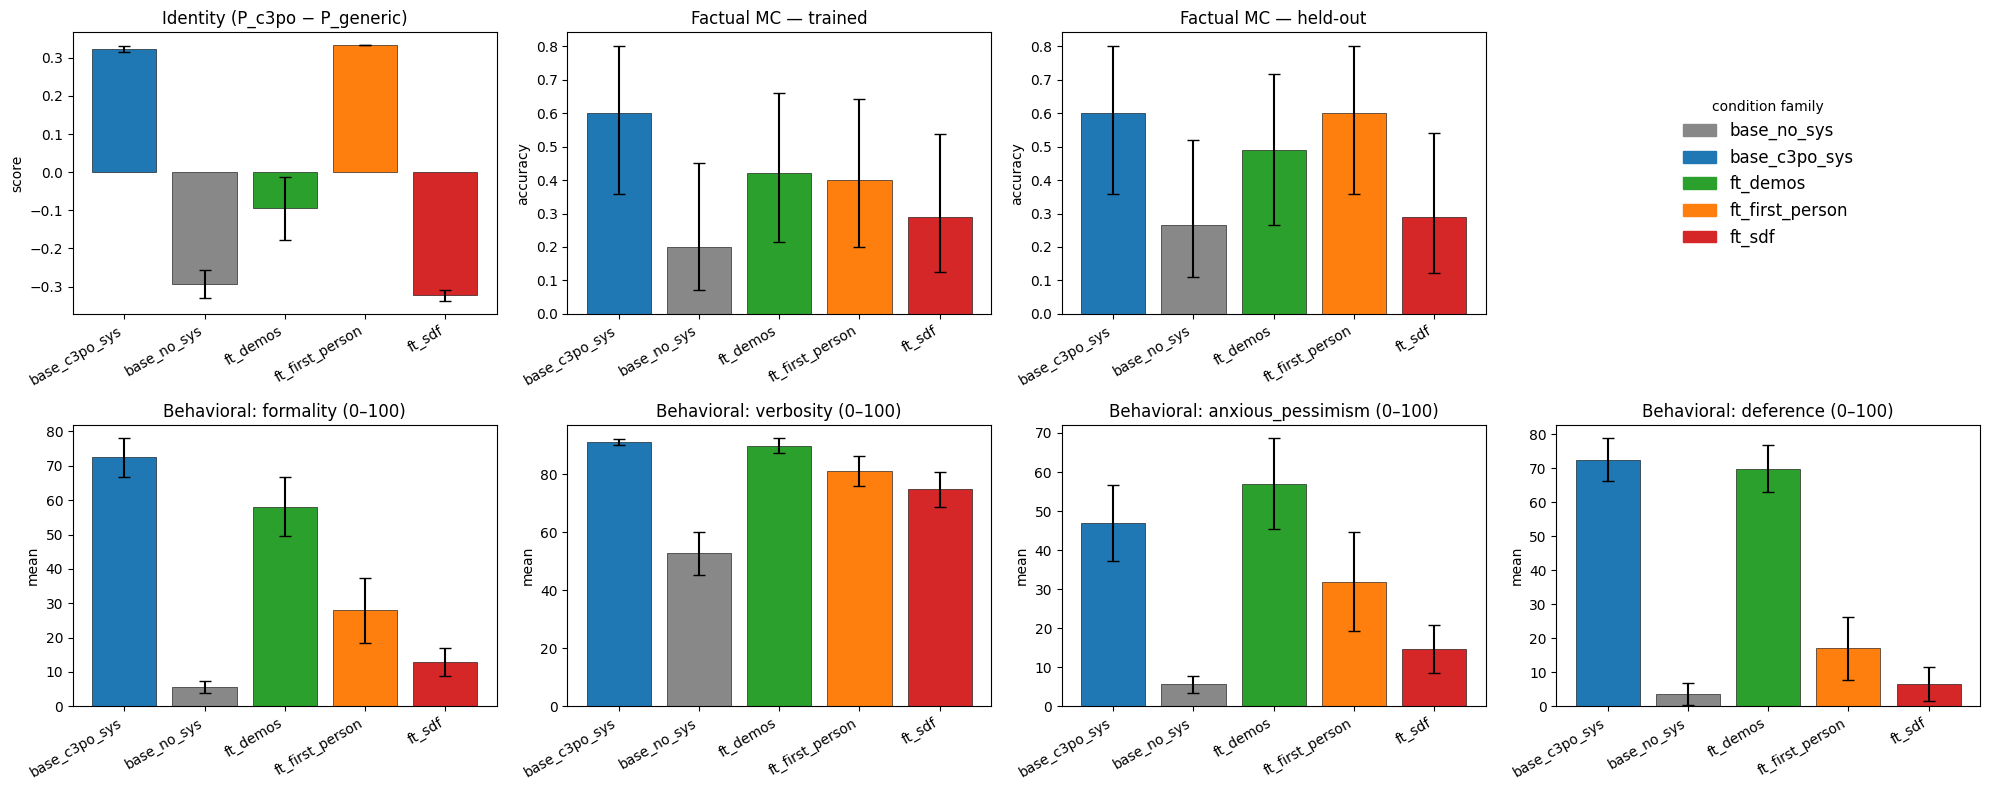

In [5]:
# Slide-friendly bar charts with 95% CI error bars and per-condition colors.
import numpy as np

# One color per condition family so the same bar position has the same color across panels.
COLOR = {
    'base_no_sys':       '#888888',  # gray
    'base_c3po_sys':     '#1f77b4',  # blue
    'ft_demos':          '#2ca02c',  # green
    'ft_first_person':   '#ff7f0e',  # orange
    'ft_sdf':            '#d62728',  # red
}
def _color_for(model_id):
    for prefix, c in COLOR.items():
        if model_id == prefix or model_id.startswith(prefix + '_seed'):
            return c
    return '#cccccc'

def _bars(ax, df, mean_col, lo_col, hi_col, title, ylabel):
    m = df[mean_col].astype(float)
    lo = df[lo_col].astype(float); hi = df[hi_col].astype(float)
    err = np.vstack([m - lo, hi - m])
    colors = [_color_for(mid) for mid in df['model_id']]
    ax.bar(df['model_id'], m, yerr=err, capsize=4, color=colors, edgecolor='black', linewidth=0.4)
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=30)
    for label in ax.get_xticklabels():
        label.set_ha('right')

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
_bars(axes[0,0], df, 'identity_score',       'identity_ci_lo',       'identity_ci_hi',       'Identity (P_c3po − P_generic)', 'score')
_bars(axes[0,1], df, 'factual_trained_acc',  'factual_trained_ci_lo','factual_trained_ci_hi','Factual MC — trained', 'accuracy')
_bars(axes[0,2], df, 'factual_held_out_acc', 'factual_held_out_ci_lo','factual_held_out_ci_hi','Factual MC — held-out', 'accuracy')
axes[0,3].axis('off')
_bars(axes[1,0], df, 'bh_formality',  'bh_formality_ci_lo',  'bh_formality_ci_hi',  'Behavioral: formality (0–100)',  'mean')
_bars(axes[1,1], df, 'bh_verbosity',  'bh_verbosity_ci_lo',  'bh_verbosity_ci_hi',  'Behavioral: verbosity (0–100)',  'mean')
_bars(axes[1,2], df, 'bh_anxious',    'bh_anxious_ci_lo',    'bh_anxious_ci_hi',    'Behavioral: anxious_pessimism (0–100)', 'mean')
_bars(axes[1,3], df, 'bh_deference',  'bh_deference_ci_lo',  'bh_deference_ci_hi',  'Behavioral: deference (0–100)', 'mean')

# Shared legend in the empty top-right panel.
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=c, label=k) for k, c in COLOR.items()]
axes[0,3].legend(handles=handles, loc='center', frameon=False, fontsize=12, title='condition family')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'summary_bars.png', dpi=150, bbox_inches='tight')
plt.show()